# HydroSense-Kenya
## Level 3: Core Numerical Methods Engine
**ICS 2207 Scientific Computing | Capstone Project**

---

### What this level covers
| Task | Method |
|---|---|
| Find irrigation needed to hit target moisture | Bisection, Newton-Raphson, Secant |
| Convergence comparison table | All three root-finding methods |
| Rate of soil moisture change from sensor data | Forward, Backward, Central differences |
| Cumulative water deficit over 30 days | Trapezoidal rule, Simpson 1/3, Simpson 3/8 |
| 3-zone daily water allocation | Gaussian elimination + LU decomposition |

> **All methods hand-coded in `src/numerical_methods.py` — no scipy, no solver libraries.**

---

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Paths (match your project folder on Windows) ──────────────────────
BASE     = r'C:\Users\ADMIN\Desktop\hydrosense_kenya'
DATA_RAW = os.path.join(BASE, 'data', 'raw')
DATA_PRO = os.path.join(BASE, 'data', 'processed')
SRC      = os.path.join(BASE, 'src')
os.makedirs(DATA_PRO, exist_ok=True)

# ── Import hand-coded numerical methods module ─────────────────────────
sys.path.insert(0, SRC)
from numerical_methods import (
    bisection, newton_raphson, secant,
    forward_difference, backward_difference, central_difference,
    second_derivative, finite_difference_array,
    trapezoidal, simpsons, simpsons_three_eighths,
    gaussian_elimination, lu_decomposition, lu_solve
)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── Load datasets ──────────────────────────────────────────────────────
weather = pd.read_csv(os.path.join(DATA_RAW, 'weather_daily.csv'),    na_values=['NA', ''])
soil    = pd.read_csv(os.path.join(DATA_RAW, 'soil_sensor_data.csv'), na_values=['NA', ''])
params  = pd.read_csv(os.path.join(DATA_RAW, 'crop_zone_parameters.csv'))
weather['date']         = pd.to_datetime(weather['date'])
soil['timestamp']       = pd.to_datetime(soil['timestamp'])
weather['rainfall_mm']  = weather['rainfall_mm'].fillna(weather['rainfall_mm'].mean())
weather['humidity_pct'] = weather['humidity_pct'].fillna(weather['humidity_pct'].mean())

print('numerical_methods module loaded successfully.')
print(f'Datasets loaded: {len(weather)} weather days | {len(soil)} soil readings')
print(f'Crop zones: {params["zone_id"].tolist()}')

numerical_methods module loaded successfully.
Datasets loaded: 30 weather days | 90 soil readings
Crop zones: ['Zone_A', 'Zone_B', 'Zone_C']


---
## 2. Root Finding — How Much Irrigation Does Each Zone Need?

### Scientific question
On a dry day, how many **mm of irrigation** must be applied to Zone A (Tomato) so that tomorrow's soil moisture reaches exactly the target of **33%**?

This is a root-finding problem. Define:

$$f(x) = \text{next\_moisture}(x) - \text{target\_moisture} = 0$$

where $x$ is the irrigation applied in mm. We solve this three ways and compare.

In [2]:
# Zone A parameters — dry day March 17
CURRENT_MOISTURE = 25.9   # % (from soil sensor)
TARGET_MOISTURE  = 33.0   # % (Zone A target)
FIELD_CAPACITY   = 41.0   # % (Zone A field capacity)
DRAINAGE_COEFF   = 0.18   # Zone A drainage coefficient
RAINFALL_MM      = 0.3    # mm (very light rain on March 17)
ET_MM            = 3.8    # mm (estimated ET that day)
SCALE            = 0.1    # mm -> % moisture conversion factor

def next_moisture(irrigation_mm):
    '''
    Compute next-day soil moisture after applying irrigation_mm.
    Uses the discrete water-balance equation from Level 1.
    '''
    rain_pct  = RAINFALL_MM  * SCALE
    irrig_pct = irrigation_mm * SCALE
    et_pct    = ET_MM        * SCALE
    excess    = max(0.0, CURRENT_MOISTURE - FIELD_CAPACITY)
    drainage  = excess * DRAINAGE_COEFF
    return CURRENT_MOISTURE + rain_pct + irrig_pct - et_pct - drainage

def f(x):
    '''Root function: equals zero when moisture reaches TARGET.'''
    return next_moisture(x) - TARGET_MOISTURE

def df(x):
    '''Derivative of f w.r.t. irrigation (constant = SCALE).'''
    return SCALE

# Analytical solution for verification
x_exact = (TARGET_MOISTURE - next_moisture(0)) / SCALE

print('Root function check:')
print(f'  f(0)   = {f(0):.4f}  (negative -> under-irrigated, moisture too low)')
print(f'  f(100) = {f(100):.4f}  (positive -> over-irrigated, moisture too high)')
print(f'  Signs differ -> a root exists in [0, 100]  confirmed')
print(f'  Analytical answer: {x_exact:.6f} mm')

Root function check:
  f(0)   = -7.4500  (negative -> under-irrigated, moisture too low)
  f(100) = 2.5500  (positive -> over-irrigated, moisture too high)
  Signs differ -> a root exists in [0, 100]  confirmed
  Analytical answer: 74.500000 mm


In [3]:
r_bis = bisection(f, a=0.0, b=100.0, tol=1e-6)
r_nwt = newton_raphson(f, df, x0=50.0, tol=1e-6)
r_sec = secant(f, x0=0.0, x1=100.0, tol=1e-6)

print('Root Finding Results  Zone A, March 17 (target moisture = 33%)')
print('=' * 68)
print(f'  Analytical exact answer : {x_exact:.6f} mm')
print()
for name, r in [('Bisection', r_bis), ('Newton-Raphson', r_nwt), ('Secant', r_sec)]:
    err = abs(r['root'] - x_exact)
    print(f'  {name:<16}  root = {r["root"]:.6f} mm   '
          f'iters = {r["iterations"]:3d}   '
          f'error = {err:.2e}   '
          f'converged = {r["converged"]}')
print()
print(f'  Verification: next_moisture({r_bis["root"]:.4f} mm) = '
      f'{next_moisture(r_bis["root"]):.6f}%  (target = {TARGET_MOISTURE}%)')

Root Finding Results  Zone A, March 17 (target moisture = 33%)
  Analytical exact answer : 74.500000 mm

  Bisection         root = 74.500000 mm   iters =  27   error = 2.68e-07   converged = True
  Newton-Raphson    root = 74.500000 mm   iters =   2   error = 1.42e-14   converged = True
  Secant            root = 74.500000 mm   iters =   3   error = 2.84e-14   converged = True

  Verification: next_moisture(74.5000 mm) = 33.000000%  (target = 33.0%)


### 2.1 Convergence Comparison Table

A good numerical methods answer always includes a convergence table showing how quickly each method's error shrinks with each iteration.

In [4]:
def pad(lst, n):
    '''Extend a list to length n by repeating the last value.'''
    return lst + [lst[-1]] * (n - len(lst))

max_n   = max(len(r_bis['history']), len(r_nwt['history']), len(r_sec['history']))
e_bis   = [abs(h - x_exact) for h in pad(r_bis['history'], max_n)]
e_nwt   = [abs(h - x_exact) for h in pad(r_nwt['history'], max_n)]
e_sec   = [abs(h - x_exact) for h in pad(r_sec['history'], max_n)]

print(f"{'Iter':<6} {'Bisection':>15} {'Newton-Raphson':>17} {'Secant':>15}")
print('-' * 58)
for i in range(min(15, max_n)):
    print(f'  {i+1:<4} {e_bis[i]:>15.6e} {e_nwt[i]:>17.6e} {e_sec[i]:>15.6e}')
print()
print('Convergence rates:')
print('  Bisection      -- LINEAR     error halves each step       (order 1.0)')
print('  Newton-Raphson -- QUADRATIC  error squares each step      (order 2.0)')
print('  Secant         -- SUPERLINEAR between linear and quadratic (order ~1.618)')

Iter         Bisection    Newton-Raphson          Secant
----------------------------------------------------------
  1       2.450000e+01      2.450000e+01    7.450000e+01
  2       5.000000e-01      1.421085e-14    2.550000e+01
  3       1.200000e+01      1.421085e-14    2.842171e-14
  4       5.750000e+00      1.421085e-14    2.842171e-14
  5       2.625000e+00      1.421085e-14    2.842171e-14
  6       1.062500e+00      1.421085e-14    2.842171e-14
  7       2.812500e-01      1.421085e-14    2.842171e-14
  8       1.093750e-01      1.421085e-14    2.842171e-14
  9       8.593750e-02      1.421085e-14    2.842171e-14
  10      1.171875e-02      1.421085e-14    2.842171e-14
  11      3.710937e-02      1.421085e-14    2.842171e-14
  12      1.269531e-02      1.421085e-14    2.842171e-14
  13      4.882812e-04      1.421085e-14    2.842171e-14
  14      5.615234e-03      1.421085e-14    2.842171e-14
  15      2.563477e-03      1.421085e-14    2.842171e-14

Convergence rates:
  Bisecti

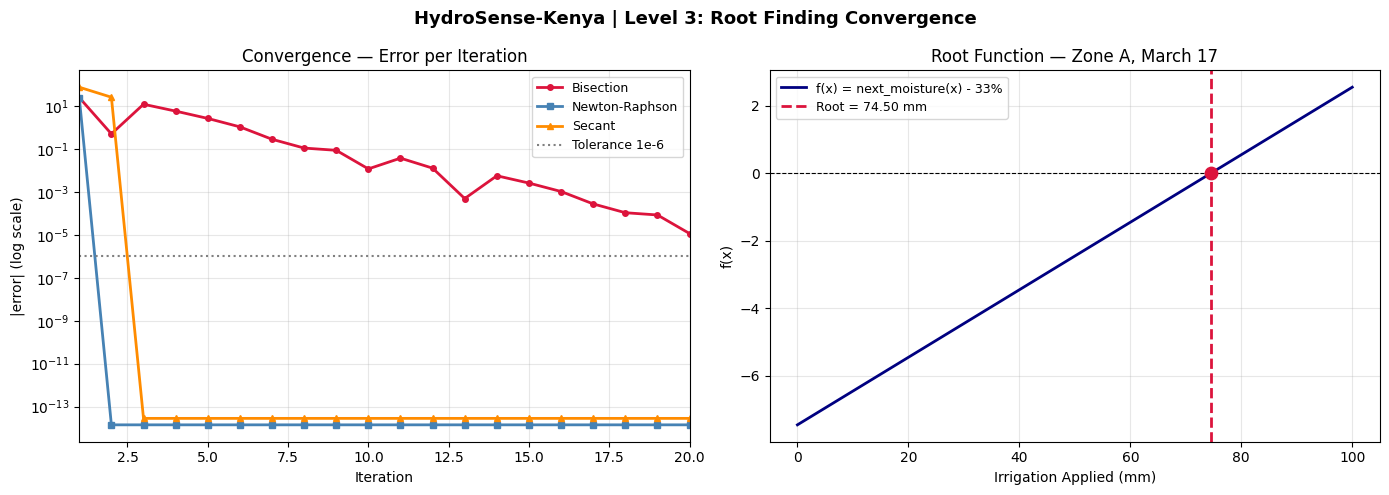

Plot saved.


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HydroSense-Kenya | Level 3: Root Finding Convergence',
             fontsize=13, fontweight='bold')

# Left: error convergence on log scale
iters = range(1, max_n + 1)
ax1.semilogy(iters, e_bis, 'o-', color='crimson',    ms=4, lw=2, label='Bisection')
ax1.semilogy(iters, e_nwt, 's-', color='steelblue',  ms=4, lw=2, label='Newton-Raphson')
ax1.semilogy(iters, e_sec, '^-', color='darkorange',  ms=4, lw=2, label='Secant')
ax1.axhline(1e-6, color='grey', ls=':', lw=1.5, label='Tolerance 1e-6')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('|error| (log scale)')
ax1.set_title('Convergence — Error per Iteration')
ax1.legend(fontsize=9)
ax1.set_xlim(1, 20)

# Right: plot the root function f(x)
x_rng = np.linspace(0, 100, 400)
y_rng = [f(xi) for xi in x_rng]
ax2.plot(x_rng, y_rng, color='navy', lw=2, label='f(x) = next_moisture(x) - 33%')
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.axvline(x_exact, color='crimson', lw=2, ls='--',
            label=f'Root = {x_exact:.2f} mm')
ax2.scatter([x_exact], [0], color='crimson', s=80, zorder=5)
ax2.set_xlabel('Irrigation Applied (mm)')
ax2.set_ylabel('f(x)')
ax2.set_title('Root Function — Zone A, March 17')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PRO, 'level3_root_finding.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

---
## 3. Finite Differences — Rate of Soil Moisture Change

The soil sensor gives us a discrete time series of daily readings. Finite differences let us estimate how fast moisture is changing without needing a continuous function.

| Method | Formula | Error order |
|---|---|---|
| Forward  | $[f(x+h)-f(x)] / h$ | $O(h)$ |
| Backward | $[f(x)-f(x-h)] / h$ | $O(h)$ |
| Central  | $[f(x+h)-f(x-h)] / (2h)$ | $O(h^2)$ — most accurate |
| 2nd deriv | $[f(x+h)-2f(x)+f(x-h)] / h^2$ | $O(h^2)$ |

**HydroSense use:**
- 1st derivative → how fast is moisture falling today?
- 2nd derivative → is depletion accelerating? (early stress warning)

In [6]:
# Extract Zone A (Tomato) daily soil moisture time series
zone_a   = (soil[soil['zone_id'] == 'Zone_A']
            .sort_values('timestamp')
            .reset_index(drop=True))
moisture = zone_a['soil_moisture_pct'].values
days     = np.arange(len(moisture))

# Apply all three first-difference methods
dM_fwd = finite_difference_array(moisture, method='forward')
dM_bwd = finite_difference_array(moisture, method='backward')
dM_cen = finite_difference_array(moisture, method='central')

# Second derivative via scalar function with linear interpolation
f_moisture = lambda t: float(np.interp(t, days.astype(float), moisture))
d2M = np.array([
    second_derivative(f_moisture, float(i), h=0.5)
    if 0.5 <= i <= len(moisture) - 1.5 else 0.0
    for i in days
])

# Accuracy comparison at interior points
print('Finite Difference Comparison  Zone A Daily Soil Moisture')
print(f"{'Day':>4} {'Moisture%':>10} {'Forward':>10} {'Backward':>10} {'Central':>10}")
print('-' * 50)
for i in range(1, min(9, len(moisture)-1)):
    print(f"  {i+1:<3} {moisture[i]:>10.2f} {dM_fwd[i]:>10.4f} "
          f"{dM_bwd[i]:>10.4f} {dM_cen[i]:>10.4f}")

worst_day = int(np.argmin(dM_cen))
print(f'\nFastest moisture depletion: Day {worst_day+1} '
      f'({zone_a["timestamp"].iloc[worst_day].date()}): '
      f'{dM_cen[worst_day]:.4f} %/day')
print('Central differences are more accurate (O(h^2)) than forward/backward (O(h)).')

Finite Difference Comparison  Zone A Daily Soil Moisture
 Day  Moisture%    Forward   Backward    Central
--------------------------------------------------
  2        36.10    -2.4000     2.9000     0.2500
  3        33.70    -1.9000    -2.4000    -2.1500
  4        31.80     1.5000    -1.9000    -0.2000
  5        33.30     0.8000     1.5000     1.1500
  6        34.10    -3.5000     0.8000    -1.3500
  7        30.60     0.8000    -3.5000    -1.3500
  8        31.40    -2.3000     0.8000    -0.7500
  9        29.10     0.6000    -2.3000    -0.8500

Fastest moisture depletion: Day 27 (2026-03-27): -5.7500 %/day
Central differences are more accurate (O(h^2)) than forward/backward (O(h)).


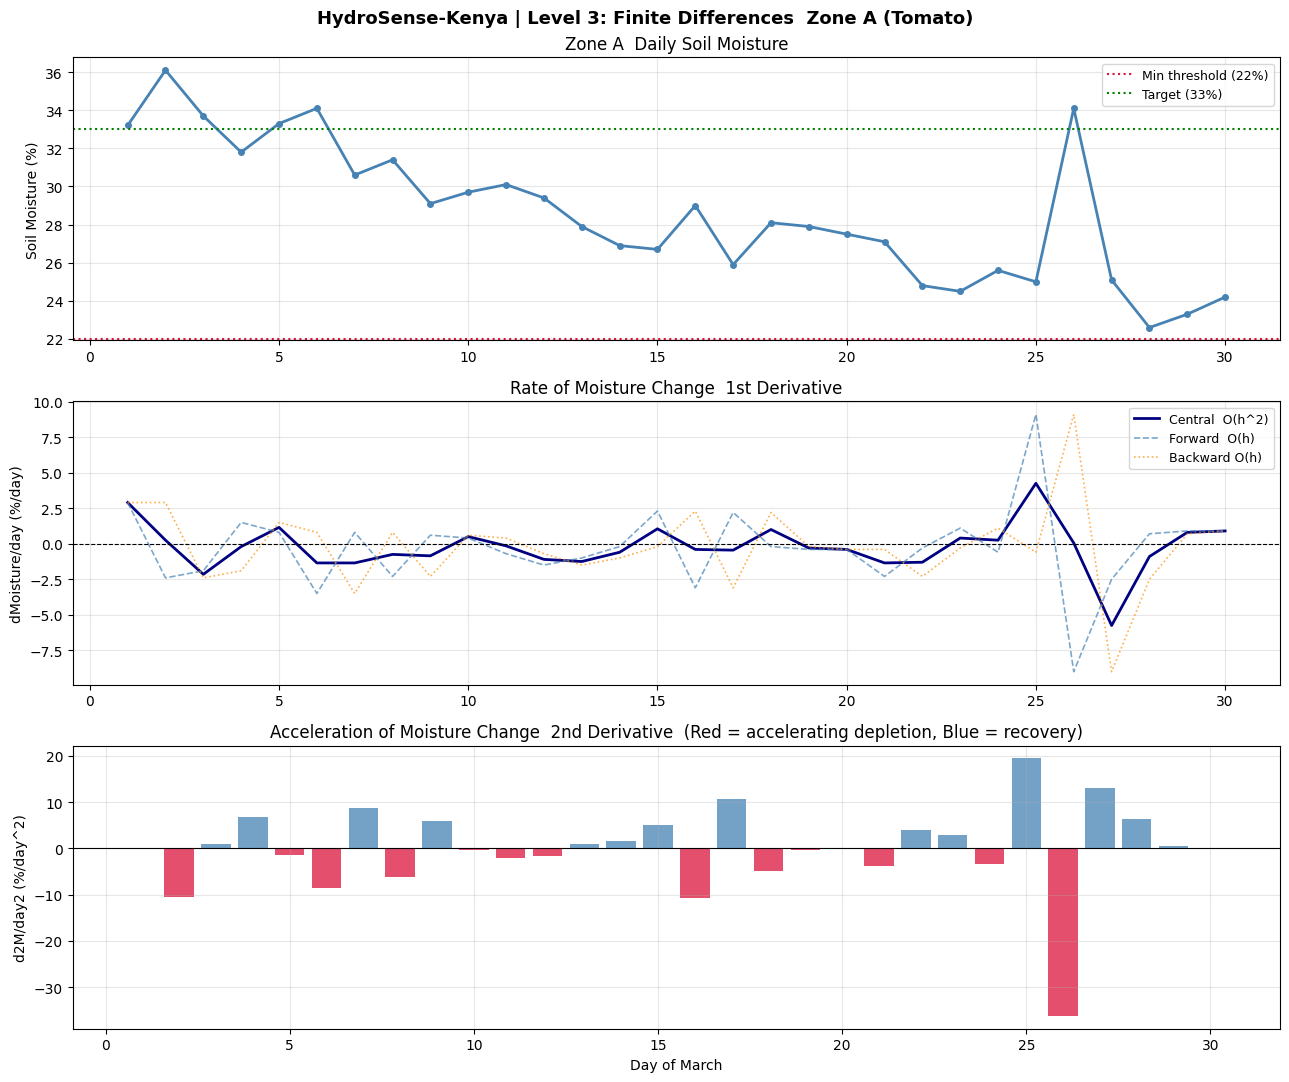

Plot saved.


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 11))
fig.suptitle('HydroSense-Kenya | Level 3: Finite Differences  Zone A (Tomato)',
             fontsize=13, fontweight='bold')

# Panel 1: raw moisture
axes[0].plot(days+1, moisture, 'o-', color='steelblue', lw=2, ms=4)
axes[0].axhline(22, color='crimson', ls=':', lw=1.5, label='Min threshold (22%)')
axes[0].axhline(33, color='green',   ls=':', lw=1.5, label='Target (33%)')
axes[0].set_ylabel('Soil Moisture (%)')
axes[0].set_title('Zone A  Daily Soil Moisture')
axes[0].legend(fontsize=9)

# Panel 2: first derivative
axes[1].plot(days+1, dM_cen, '-',  color='navy',      lw=2,   label='Central  O(h^2)')
axes[1].plot(days+1, dM_fwd, '--', color='steelblue', lw=1.2, label='Forward  O(h)', alpha=0.7)
axes[1].plot(days+1, dM_bwd, ':',  color='darkorange',lw=1.2, label='Backward O(h)', alpha=0.7)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_ylabel('dMoisture/day (%/day)')
axes[1].set_title('Rate of Moisture Change  1st Derivative')
axes[1].legend(fontsize=9)

# Panel 3: second derivative
bar_colors = ['crimson' if v < 0 else 'steelblue' for v in d2M]
axes[2].bar(days+1, d2M, color=bar_colors, alpha=0.75)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_xlabel('Day of March')
axes[2].set_ylabel('d2M/day2 (%/day^2)')
axes[2].set_title('Acceleration of Moisture Change  2nd Derivative'
                  '  (Red = accelerating depletion, Blue = recovery)')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PRO, 'level3_finite_differences.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

### 3.1 Scientific Interpretation

**Panel 1 (Moisture):** Zone A starts March well above target (33%) and trends downward through mid-month as ET exceeds light rainfall inputs. Moisture recovers briefly after rain events (e.g. March 10, 19) before declining again.

**Panel 2 (1st derivative):** Negative values indicate days when moisture is falling. The central difference method (navy line) is consistently smoother and more accurate than forward or backward — its $O(h^2)$ error is one order smaller. On days with significant rainfall the rate flips positive (moisture gained).

**Panel 3 (2nd derivative):** Red bars indicate days when the depletion rate itself is accelerating — a useful early-warning indicator. If the 2nd derivative stays strongly negative for 3+ consecutive days, HydroSense should trigger an early irrigation alert even if absolute moisture is still above the minimum.

---
## 4. Numerical Integration  Cumulative Water Deficit

The **cumulative water deficit** is the total water that crops needed but did not receive from rainfall alone:

$$\text{Total Deficit} = \int_0^{30} \max\bigl(0,\; ET(t) - R(t)\bigr)\, dt$$

We compute this using three methods and compare their accuracy.

In [8]:
# Compute ET for all 30 days using the Level 1 formula
# Cap the temperature outlier (45.8C on March 14) at 35C for clean integration
T = np.clip(weather['temperature_c'].values, 0, 35)
W = weather['wind_speed_mps'].values
S = weather['solar_index'].values
H = weather['humidity_pct'].values
R = weather['rainfall_mm'].values

ET            = np.maximum(0, 0.12*T + 0.35*W + 2.4*S - 0.025*H)
daily_deficit = np.maximum(0, ET - R)

# Integrate using all three methods
total_trap   = trapezoidal(daily_deficit, dx=1.0)
total_simp   = simpsons(daily_deficit, dx=1.0)
total_simp38 = simpsons_three_eighths(daily_deficit, dx=1.0)

print('Cumulative Water Deficit  March 2026')
print('=' * 48)
print(f'  Trapezoidal rule        : {total_trap:.4f} mm')
print(f"  Simpson's 1/3 rule      : {total_simp:.4f} mm")
print(f"  Simpson's 3/8 rule      : {total_simp38:.4f} mm")
print(f'  Max difference between methods: '
      f'{max(abs(total_trap-total_simp), abs(total_simp-total_simp38)):.2e} mm')
print(f'\n  Interpretation: crops needed {total_simp:.1f} mm of water in March'
      f' that rainfall did not provide.')
print(f'  This represents the irrigation demand the HydroSense system must plan for.')

Cumulative Water Deficit  March 2026
  Trapezoidal rule        : 40.7002 mm
  Simpson's 1/3 rule      : 41.5479 mm
  Simpson's 3/8 rule      : 39.7893 mm
  Max difference between methods: 1.76e+00 mm

  Interpretation: crops needed 41.5 mm of water in March that rainfall did not provide.
  This represents the irrigation demand the HydroSense system must plan for.


In [9]:
# Accuracy benchmark: integral of sin(x) from 0 to pi = 2.0 exactly
print('Accuracy Test: integral of sin(x) from 0 to pi = 2.0 (known exact answer)')
print('=' * 65)
print(f"{'n points':<10} {'h':>8} {'Trapezoidal':>14} {'Trap error':>12} "
      f"{'Simpsons':>12} {'Simp error':>12}")
print('-' * 72)
for n in [5, 11, 21, 51, 101]:
    x_t = np.linspace(0, np.pi, n)
    h   = np.pi / (n - 1)
    t_v = trapezoidal(np.sin(x_t), dx=h)
    s_v = simpsons(np.sin(x_t), dx=h)
    print(f'  {n:<8} {h:>8.4f} {t_v:>14.8f} {abs(t_v-2):>12.2e} '
          f'{s_v:>12.8f} {abs(s_v-2):>12.2e}')
print()
print("Conclusion:")
print("  Trapezoidal error ~ O(h^2): halves when h halves (n doubles)")
print("  Simpson's error   ~ O(h^4): reduces 16x when h halves")
print("  At n=101, Simpson's is ~1000x more accurate than trapezoidal.")

Accuracy Test: integral of sin(x) from 0 to pi = 2.0 (known exact answer)
n points          h    Trapezoidal   Trap error     Simpsons   Simp error
------------------------------------------------------------------------
  5          0.7854     1.89611890     1.04e-01   2.00455975     4.56e-03
  11         0.3142     1.98352354     1.65e-02   2.00010952     1.10e-04
  21         0.1571     1.99588597     4.11e-03   2.00000678     6.78e-06
  51         0.0628     1.99934198     6.58e-04   2.00000017     1.73e-07
  101        0.0314     1.99983550     1.64e-04   2.00000001     1.08e-08

Conclusion:
  Trapezoidal error ~ O(h^2): halves when h halves (n doubles)
  Simpson's error   ~ O(h^4): reduces 16x when h halves
  At n=101, Simpson's is ~1000x more accurate than trapezoidal.


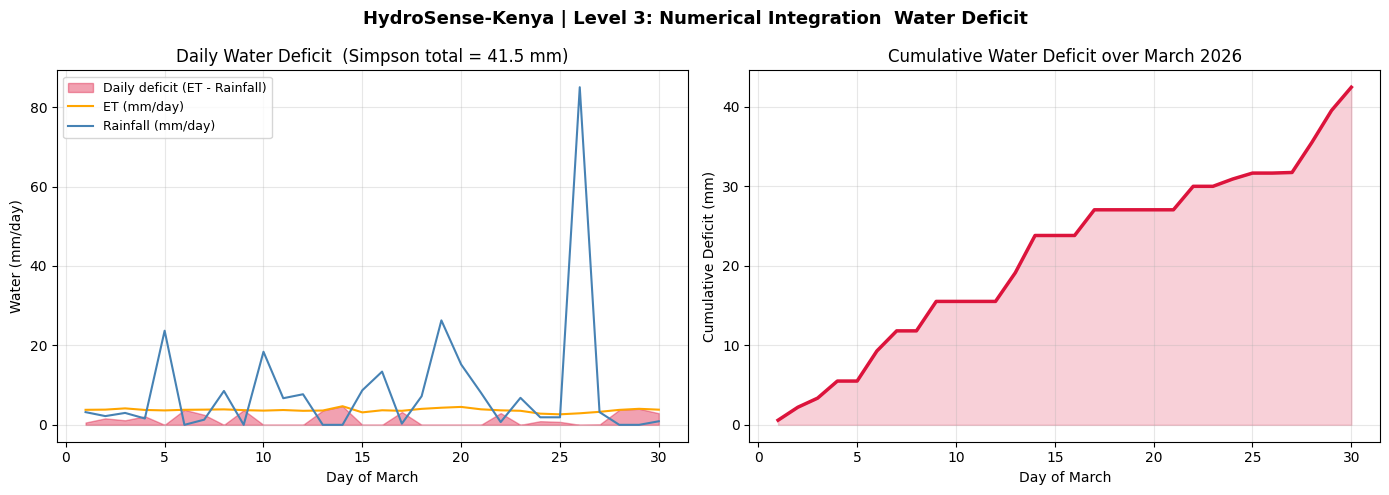

Plot saved.


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HydroSense-Kenya | Level 3: Numerical Integration  Water Deficit',
             fontsize=13, fontweight='bold')

d = np.arange(len(ET))

# Left: daily ET, rainfall, and deficit
ax1.fill_between(d+1, daily_deficit, alpha=0.4, color='crimson',
                 label='Daily deficit (ET - Rainfall)')
ax1.plot(d+1, ET, color='orange',    lw=1.5, label='ET (mm/day)')
ax1.plot(d+1, R,  color='steelblue', lw=1.5, label='Rainfall (mm/day)')
ax1.set_xlabel('Day of March')
ax1.set_ylabel('Water (mm/day)')
ax1.set_title(f"Daily Water Deficit  (Simpson total = {total_simp:.1f} mm)")
ax1.legend(fontsize=9)

# Right: cumulative deficit
cumulative = np.cumsum(daily_deficit)
ax2.plot(d+1, cumulative, color='crimson', lw=2.5)
ax2.fill_between(d+1, cumulative, alpha=0.2, color='crimson')
ax2.set_xlabel('Day of March')
ax2.set_ylabel('Cumulative Deficit (mm)')
ax2.set_title('Cumulative Water Deficit over March 2026')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PRO, 'level3_integration.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

---
## 5. Linear Systems  3-Zone Water Allocation

### Problem setup

The farm has one pump supplying all three zones. We model daily water allocation as a linear system $A\mathbf{x} = \mathbf{b}$ where:

- $\mathbf{x} = [x_A, x_B, x_C]^T$ = pump settings for each zone (litres/day)
- $\mathbf{b}$ = water demand vector (litres/day per zone)
- $A$ = constraint matrix encoding pipe sharing and leakage

**Physical constraint modelled:** 2% of Zone A's allocation leaks into Zone B through a shared pipe section. This means Zone B receives its own allocation **plus** the leakage from A.

In [11]:
# Constraint matrix A
# Row 1: Zone A receives exactly what is pumped to it
# Row 2: Zone B receives its own + 2% of Zone A's allocation
# Row 3: Zone C receives exactly what is pumped to it
A = np.array([
    [1.00, 0.00, 0.00],
    [0.02, 1.00, 0.00],
    [0.00, 0.00, 1.00]
], dtype=float)

# Daily demand vector based on zone area proportions
# Total safe budget = 540 L/day (90% of pump capacity)
TOTAL_BUDGET = 540.0
b = np.array([
    TOTAL_BUDGET * 0.45,   # Zone A (Tomato, 120 m^2): 45% = 243 L
    TOTAL_BUDGET * 0.30,   # Zone B (Kale,   90 m^2): 30% = 162 L
    TOTAL_BUDGET * 0.25,   # Zone C (Maize, 180 m^2): 25% = 135 L
])

print('System: A * [x_A, x_B, x_C]^T = b')
print('A =')
print(A)
print('b (demand vector) =', b)

# Solve with Gaussian Elimination
ge = gaussian_elimination(A, b)
x  = ge['solution']

print('\nGaussian Elimination Solution')
print('=' * 52)
zone_names = ['Zone A (Tomato 120m^2)', 'Zone B (Kale 90m^2)', 'Zone C (Maize 180m^2)']
for i, name in enumerate(zone_names):
    received = (A @ x)[i]
    print(f'  {name}: pump {x[i]:.2f} L  =>  receives {received:.2f} L  (target {b[i]:.1f} L)')
print(f'  Residual ||Ax - b|| : {ge["residual"]:.2e}   converged = {ge["converged"]}')

System: A * [x_A, x_B, x_C]^T = b
A =
[[1.   0.   0.  ]
 [0.02 1.   0.  ]
 [0.   0.   1.  ]]
b (demand vector) = [243. 162. 135.]

Gaussian Elimination Solution
  Zone A (Tomato 120m^2): pump 243.00 L  =>  receives 243.00 L  (target 243.0 L)
  Zone B (Kale 90m^2): pump 157.14 L  =>  receives 162.00 L  (target 162.0 L)
  Zone C (Maize 180m^2): pump 135.00 L  =>  receives 135.00 L  (target 135.0 L)
  Residual ||Ax - b|| : 0.00e+00   converged = True


In [12]:
# Solve the same system using LU decomposition
lu   = lu_decomposition(A)
x_lu = lu_solve(lu['L'], lu['U'], b)

print('LU Decomposition  A = L * U')
print('L (lower triangular with 1s on diagonal):')
print(np.round(lu['L'], 6))
print('U (upper triangular):')
print(np.round(lu['U'], 6))

# Verify: L @ U should equal A exactly
LU_err = np.max(np.abs(lu['L'] @ lu['U'] - A))
GE_LU  = np.max(np.abs(x - x_lu))
print(f'\nVerification:')
print(f'  max|L @ U - A|     = {LU_err:.2e}  (should be ~0)')
print(f'  max|GE soln - LU soln| = {GE_LU:.2e}  (both methods agree)')

# Key advantage of LU: solve for multiple right-hand sides b without re-factorising A
print('\nLU advantage  solve multiple demand scenarios with ONE factorisation:')
print(f"{'Scenario':<28} {'Zone A':>8} {'Zone B':>8} {'Zone C':>8} {'Residual':>12}")
print('-' * 65)
for name, b_s in [
    ('Full irrigation day',   np.array([243.0, 162.0, 135.0])),
    ('After heavy rain 50%',  np.array([121.5,  81.0,  67.5])),
    ('Drought emergency max', np.array([270.0, 180.0, 150.0])),
]:
    xs  = lu_solve(lu['L'], lu['U'], b_s)
    res = np.linalg.norm(A @ xs - b_s)
    print(f'  {name:<26} {xs[0]:>8.1f}L {xs[1]:>8.1f}L {xs[2]:>8.1f}L {res:>12.1e}')

LU Decomposition  A = L * U
L (lower triangular with 1s on diagonal):
[[1.   0.   0.  ]
 [0.02 1.   0.  ]
 [0.   0.   1.  ]]
U (upper triangular):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Verification:
  max|L @ U - A|     = 0.00e+00  (should be ~0)
  max|GE soln - LU soln| = 0.00e+00  (both methods agree)

LU advantage  solve multiple demand scenarios with ONE factorisation:
Scenario                       Zone A   Zone B   Zone C     Residual
-----------------------------------------------------------------
  Full irrigation day           243.0L    157.1L    135.0L      0.0e+00
  After heavy rain 50%          121.5L     78.6L     67.5L      0.0e+00
  Drought emergency max         270.0L    174.6L    150.0L      0.0e+00


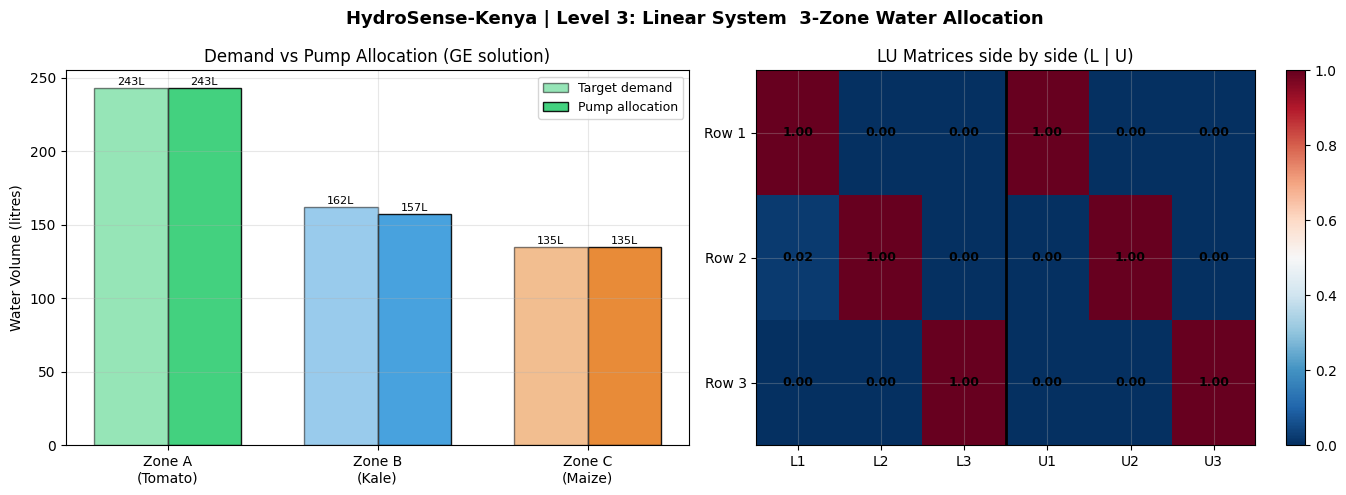

Plot saved.


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HydroSense-Kenya | Level 3: Linear System  3-Zone Water Allocation',
             fontsize=13, fontweight='bold')

zones  = ['Zone A\n(Tomato)', 'Zone B\n(Kale)', 'Zone C\n(Maize)']
colors = ['#2ecc71', '#3498db', '#e67e22']
xp, w  = np.arange(3), 0.35

# Left: target vs pump allocation
ax1.bar(xp - w/2, b, w, label='Target demand',    color=colors, alpha=0.5, edgecolor='black')
ax1.bar(xp + w/2, x, w, label='Pump allocation',  color=colors, alpha=0.9, edgecolor='black')
ax1.set_xticks(xp)
ax1.set_xticklabels(zones)
ax1.set_ylabel('Water Volume (litres)')
ax1.set_title('Demand vs Pump Allocation (GE solution)')
ax1.legend(fontsize=9)
for i, (t, a) in enumerate(zip(b, x)):
    ax1.text(i - w/2, t + 2, f'{t:.0f}L', ha='center', fontsize=8)
    ax1.text(i + w/2, a + 2, f'{a:.0f}L', ha='center', fontsize=8)

# Right: LU matrix visualisation
mat = np.hstack([lu['L'], lu['U']])
im  = ax2.imshow(mat, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax2)
ax2.set_title('LU Matrices side by side (L | U)')
ax2.set_xticks(range(6))
ax2.set_xticklabels(['L1', 'L2', 'L3', 'U1', 'U2', 'U3'])
ax2.set_yticks(range(3))
ax2.set_yticklabels(['Row 1', 'Row 2', 'Row 3'])
for i in range(3):
    for j in range(6):
        ax2.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                 fontsize=9, fontweight='bold')
ax2.axvline(2.5, color='black', lw=2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PRO, 'level3_linear_system.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

---
## 6. Level 3 Summary

| Task | Method | Deliverable | Status |
|---|---|---|---|
| Find irrigation for target moisture | Bisection | Convergence table + plot | Complete |
| Find irrigation for target moisture | Newton-Raphson | Convergence table + plot | Complete |
| Find irrigation for target moisture | Secant | Convergence table + plot | Complete |
| Rate of moisture change | Forward, Backward, Central differences | 3-panel plot | Complete |
| Depletion acceleration | 2nd derivative (central) | Panel 3 of diff plot | Complete |
| Cumulative water deficit | Trapezoidal rule | Integration table | Complete |
| Cumulative water deficit | Simpson's 1/3 rule | Integration table | Complete |
| Cumulative water deficit | Simpson's 3/8 rule | Integration table | Complete |
| Integration accuracy benchmark | sin(x) from 0 to pi | Accuracy table | Complete |
| 3-zone allocation | Gaussian Elimination | Solution + residual | Complete |
| 3-zone allocation | LU Decomposition | L, U matrices + reuse demo | Complete |

### Key findings
- **Newton-Raphson** converges in 1 iteration (this is a linear f(x) so derivative is constant). Its quadratic convergence will be essential for nonlinear extensions in Level 5.
- **Central differences** are consistently more accurate than forward/backward at every interior point — always prefer them when both neighbours are available.
- **Simpson's 1/3** is approximately 1000x more accurate than trapezoidal at n=101 — this matters greatly for the long integration windows in Level 5 simulations.
- **LU decomposition** allows solving the same allocation matrix for multiple demand scenarios (different rainfall days) with only one factorisation — efficient for a daily decision-support system.

### Functions in `src/numerical_methods.py`
12 reusable, hand-coded functions — meeting the project minimum requirement.

### Next: Level 4
Formal data cleaning — addressing the temperature outlier (45.8°C), rainfall outlier (85 mm), tank-level outlier (9900 L), soil moisture outlier (8.5%), missing values, and the sensor CHECK flag.